# 📊 Telco Customer Churn Analysis & Prediction

**Objective:** Analyze customer churn patterns and build a high-performance ML model to predict whether a customer will churn.

**Dataset:** Telco Customer Churn (7,043 customers × 21 features)

---
## Table of Contents
1. Data Loading & Inspection
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training & Comparison
6. Model Evaluation & Selection
7. Save Best Model


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve)
from imblearn.over_sampling import SMOTE
import joblib

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 1. Data Loading & Inspection

In [4]:
# Load the dataset
df = pd.read_csv('telecom_customer_churn.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Total Customers: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
df.head(10)

Dataset Shape: (7043, 38)
Total Customers: 7,043
Total Features: 38


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
5,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,...,Credit Card,69.40,571.45,0.00,0,150.93,722.38,Stayed,NaN,NaN
6,0013-SMEOE,Female,67,Yes,0,Lompoc,93437,34.757477,-120.550507,1,...,Bank Withdrawal,109.70,7904.25,0.00,0,707.16,8611.41,Stayed,NaN,NaN
7,0014-BMAQU,Male,52,Yes,0,Napa,94558,38.489789,-122.270110,8,...,Credit Card,84.65,5377.80,0.00,20,816.48,6214.28,Stayed,NaN,NaN
8,0015-UOCOJ,Female,68,No,0,Simi Valley,93063,34.296813,-118.685703,0,...,Bank Withdrawal,48.20,340.35,0.00,0,73.71,414.06,Stayed,NaN,NaN
9,0016-QLJIS,Female,43,Yes,1,Sheridan,95681,38.984756,-121.345074,3,...,Credit Card,90.45,5957.90,0.00,0,1849.90,7807.80,Stayed,NaN,NaN


In [5]:
# Data types and info
print("=" * 60)
print("DATA TYPES & NON-NULL COUNTS")
print("=" * 60)
df.info()


DATA TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                      

In [6]:
# Statistical summary
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,7043,7043,0002-ORFBO,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,7043.0,NaN,NaN,NaN,46.509726,16.750352,19.0,32.0,46.0,60.0,80.0
Married,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Dependents,7043.0,NaN,NaN,NaN,0.468692,0.962802,0.0,0.0,0.0,0.0,9.0
City,7043,1106,Los Angeles,293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93486.070567,1856.767505,90001.0,92101.0,93518.0,95329.0,96150.0
Latitude,7043.0,NaN,NaN,NaN,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.756684,2.154425,-124.301372,-121.78809,-119.595293,-117.969795,-114.192901
Number of Referrals,7043.0,NaN,NaN,NaN,1.951867,3.001199,0.0,0.0,0.0,3.0,11.0


In [7]:
# Check for missing values
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No null values found")
print(f"\nTotal null values: {df.isnull().sum().sum()}")




MISSING VALUES
Offer                                3877
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                     1526
Streaming Music                      1526
Unlimited Data                       1526
Churn Category                       5174
Churn Reason                         5174
dtype: int64

Total null values: 30849


## 2. Data Cleaning & Preprocessing

In [8]:
# Drop unnecessary columns
df.drop(['Customer ID', 'Zip Code', 'Latitude', 'Longitude', 'Churn Category', 'Churn Reason'], axis=1, inplace=True)

# Create binary churn target (1 = Churned, 0 = Stayed/Joined)
df['Churn'] = (df['Customer Status'] == 'Churned').astype(int)
df.drop('Customer Status', axis=1, inplace=True)

# Handle missing values in categorical columns
for col in df.select_dtypes(include='object').columns:
    if col != 'Churn':
        df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown', inplace=True)

# Convert numeric columns that may have been read as strings
numeric_cols = ['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months',
                'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 
                'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges',
                'Total Long Distance Charges', 'Total Revenue']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print("✅ Data cleaning complete!")
print(f"Final shape: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())

✅ Data cleaning complete!
Final shape: (7043, 32)
Remaining nulls: 0

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

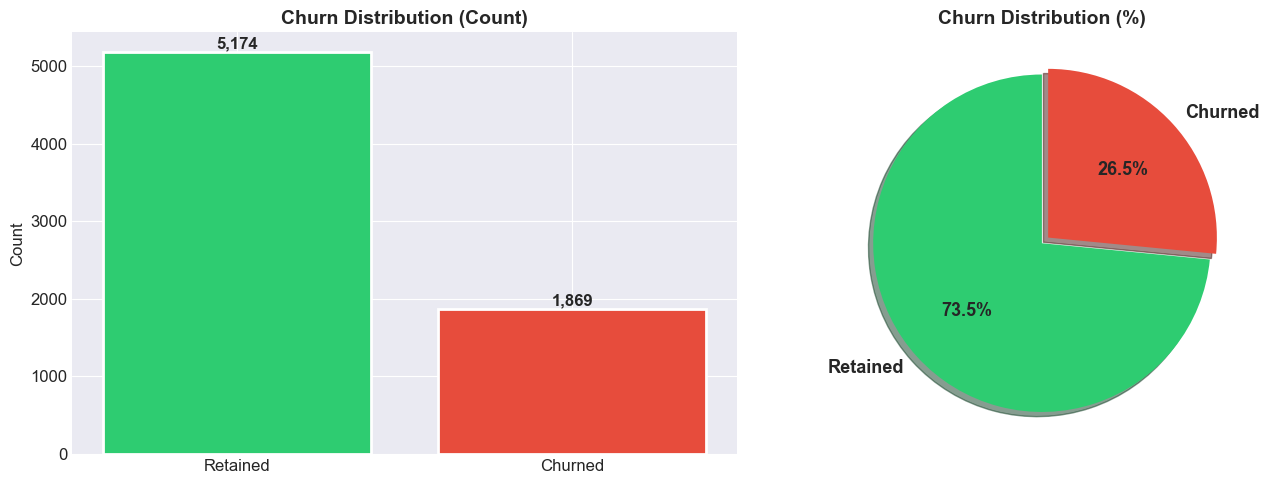


Churn Rate: 26.5%
Retention Rate: 73.5%


In [9]:
# Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
churn_labels = {1: 'Churned', 0: 'Retained'}
churn_counts = df['Churn'].value_counts().sort_index()
churn_counts.index = churn_counts.index.map(churn_labels)

colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 13, 'fontweight': 'bold'},
            shadow=True)
axes[1].set_title('Churn Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nChurn Rate: {(df['Churn'] == 1).mean():.1%}")
print(f"Retention Rate: {(df['Churn'] == 0).mean():.1%}")

### 3.2 Numerical Features Analysis

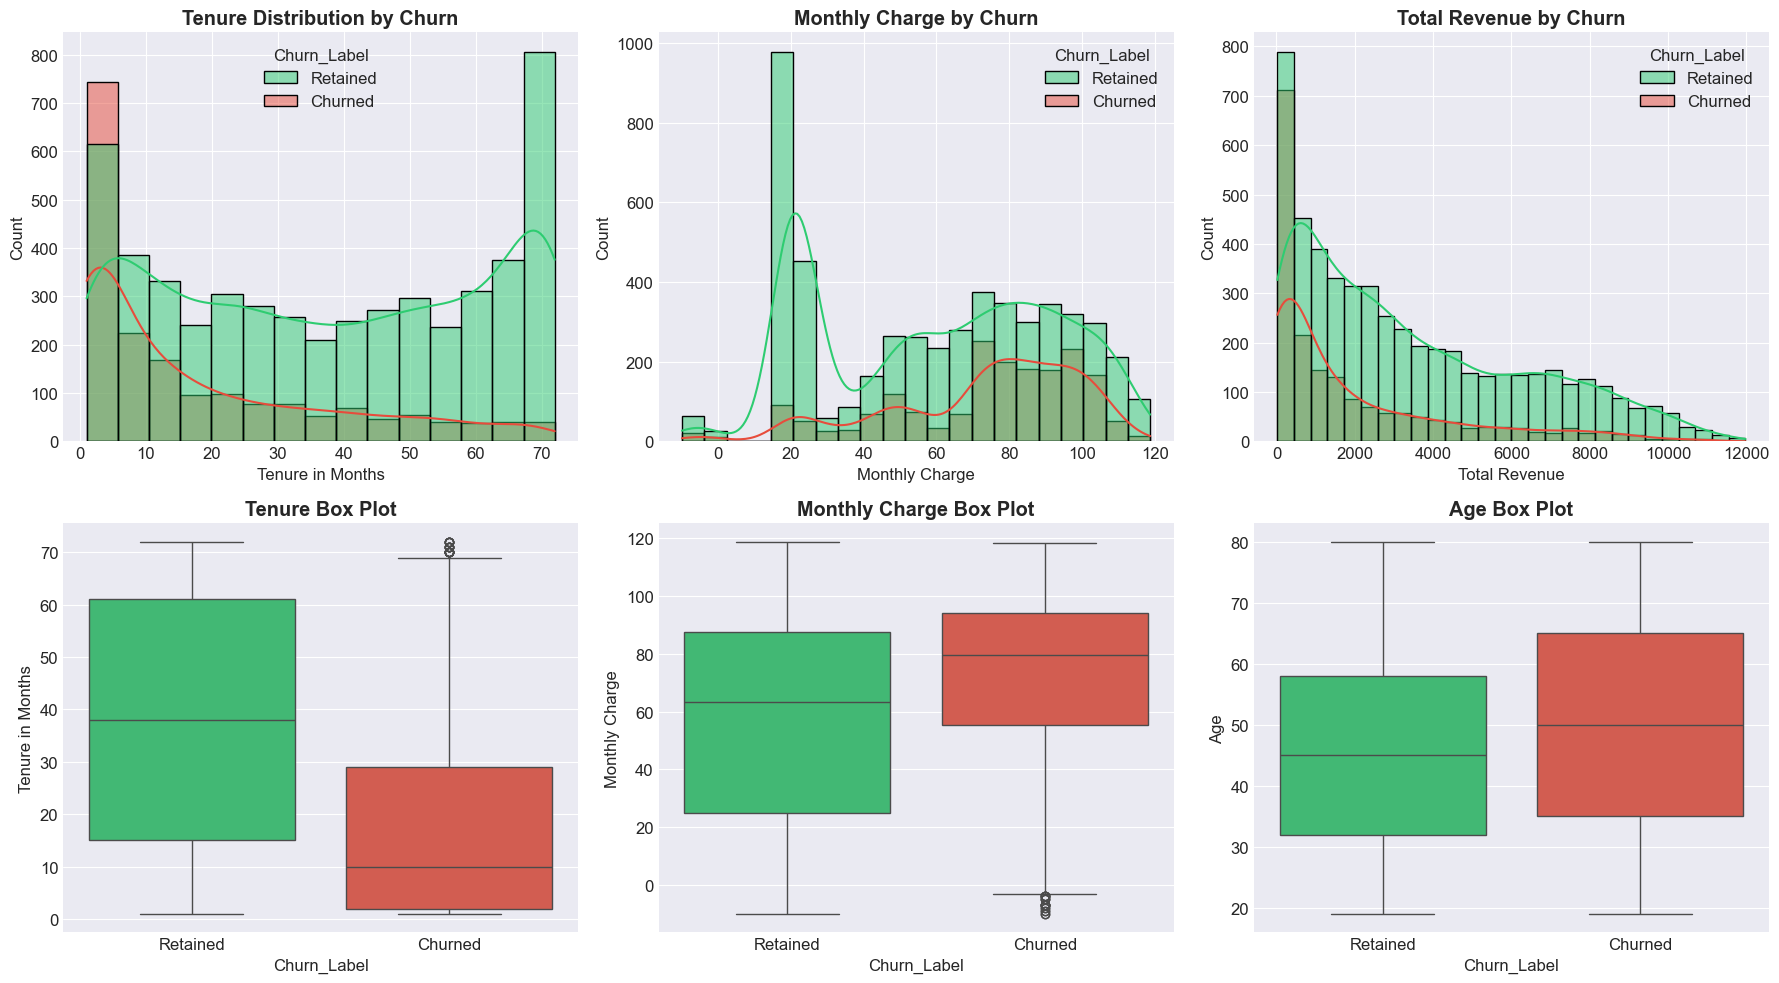

In [10]:
# Distribution of Numerical Features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Create binary labels for visualization
churn_map = {1: 'Churned', 0: 'Retained'}
df['Churn_Label'] = df['Churn'].map(churn_map)
colors = ['#2ecc71', '#e74c3c']

# Tenure distribution
sns.histplot(data=df, x='Tenure in Months', hue='Churn_Label', kde=True, ax=axes[0, 0], palette=colors)
axes[0, 0].set_title('Tenure Distribution by Churn', fontweight='bold')

# Monthly Charges distribution
sns.histplot(data=df, x='Monthly Charge', hue='Churn_Label', kde=True, ax=axes[0, 1], palette=colors)
axes[0, 1].set_title('Monthly Charge by Churn', fontweight='bold')

# Total Revenue distribution
sns.histplot(data=df, x='Total Revenue', hue='Churn_Label', kde=True, ax=axes[0, 2], palette=colors)
axes[0, 2].set_title('Total Revenue by Churn', fontweight='bold')

# Box plots
sns.boxplot(data=df, x='Churn_Label', y='Tenure in Months', palette=colors, ax=axes[1, 0])
axes[1, 0].set_title('Tenure Box Plot', fontweight='bold')

sns.boxplot(data=df, x='Churn_Label', y='Monthly Charge', palette=colors, ax=axes[1, 1])
axes[1, 1].set_title('Monthly Charge Box Plot', fontweight='bold')

sns.boxplot(data=df, x='Churn_Label', y='Age', palette=colors, ax=axes[1, 2])
axes[1, 2].set_title('Age Box Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('numerical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop('Churn_Label', axis=1, inplace=True)

### 3.3 Categorical Features & Churn Rate

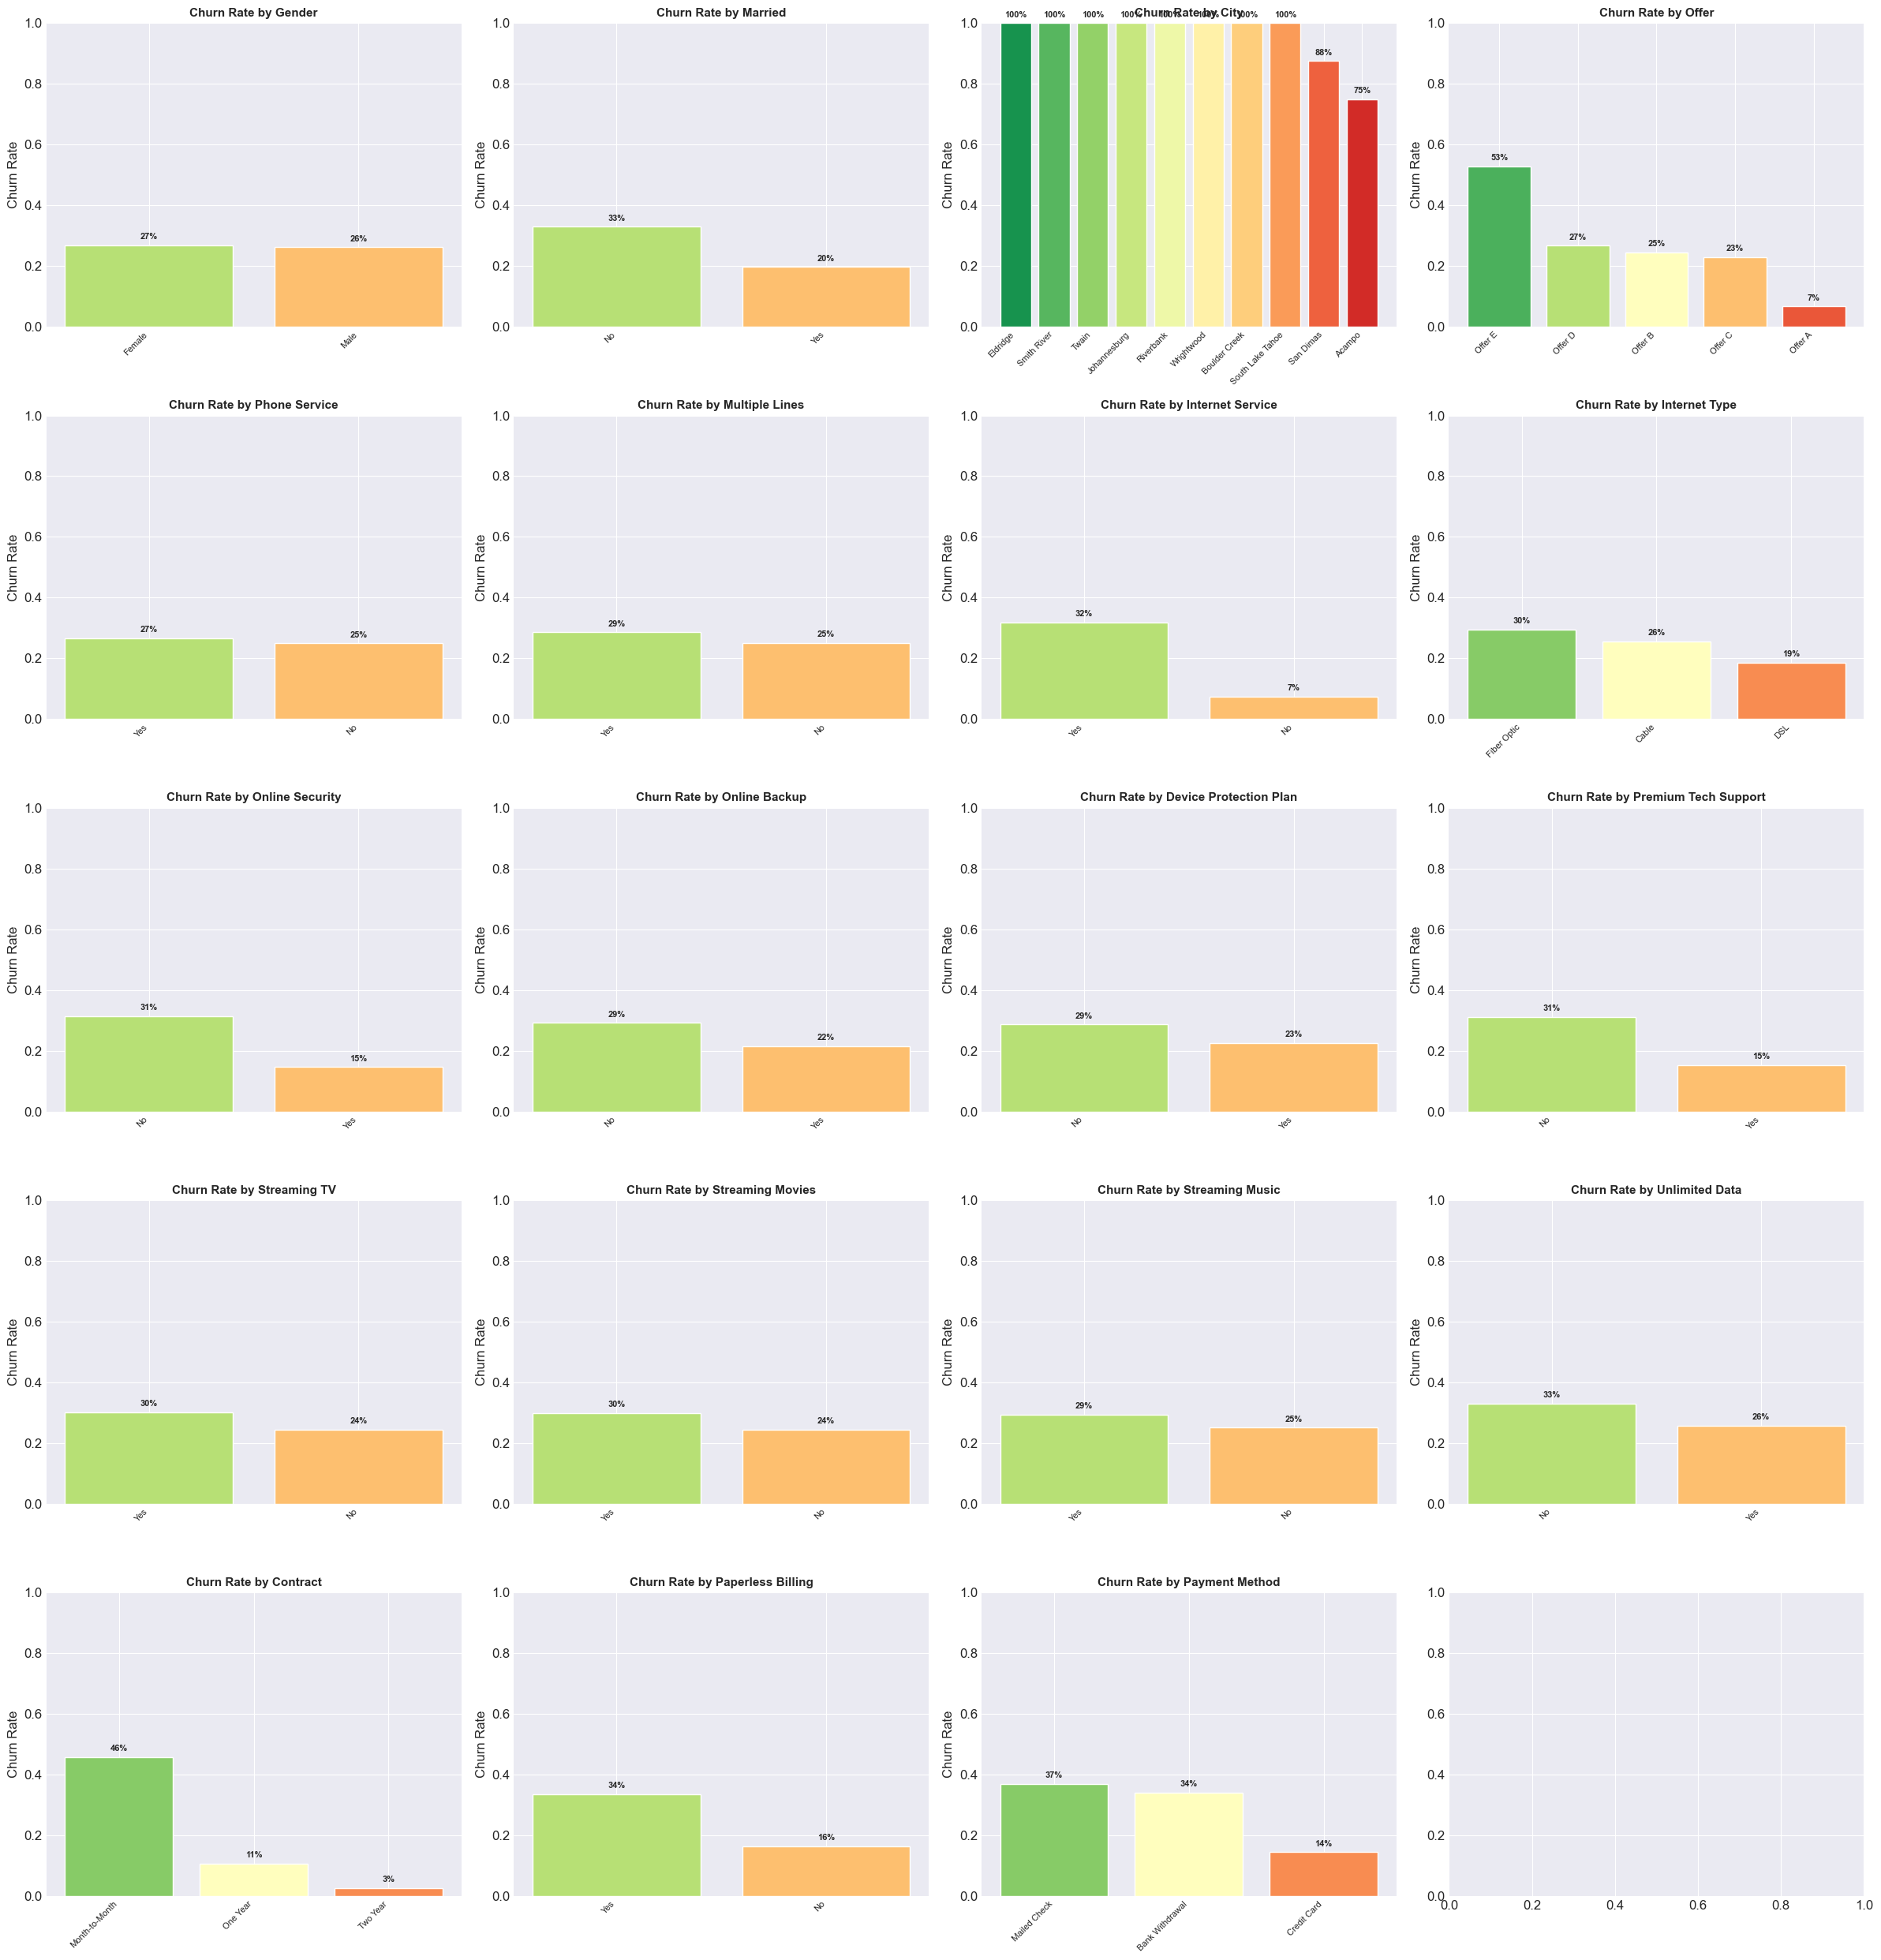

In [11]:
# Churn rate by categorical features
cat_features = ['Gender', 'Married', 'City', 'Offer', 'Phone Service', 'Multiple Lines',
                'Internet Service', 'Internet Type', 'Online Security', 'Online Backup',
                'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 
                'Streaming Movies', 'Streaming Music', 'Unlimited Data',
                'Contract', 'Paperless Billing', 'Payment Method']

# Filter to only existing columns
cat_features = [col for col in cat_features if col in df.columns]

fig, axes = plt.subplots(5, 4, figsize=(24, 25))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    if df[col].dtype == 'object':
        churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 1).mean()).sort_values(ascending=False).head(10)
        bars = axes[i].bar(range(len(churn_rate)), churn_rate.values, 
                           color=sns.color_palette('RdYlGn_r', len(churn_rate)), edgecolor='white')
        axes[i].set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
        axes[i].set_xticks(range(len(churn_rate)))
        axes[i].set_xticklabels(churn_rate.index, rotation=45, ha='right', fontsize=8)
        axes[i].set_ylabel('Churn Rate')
        axes[i].set_ylim(0, 1)
        for j, v in enumerate(churn_rate.values):
            axes[i].text(j, v + 0.02, f'{v:.0%}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Correlation Heatmap

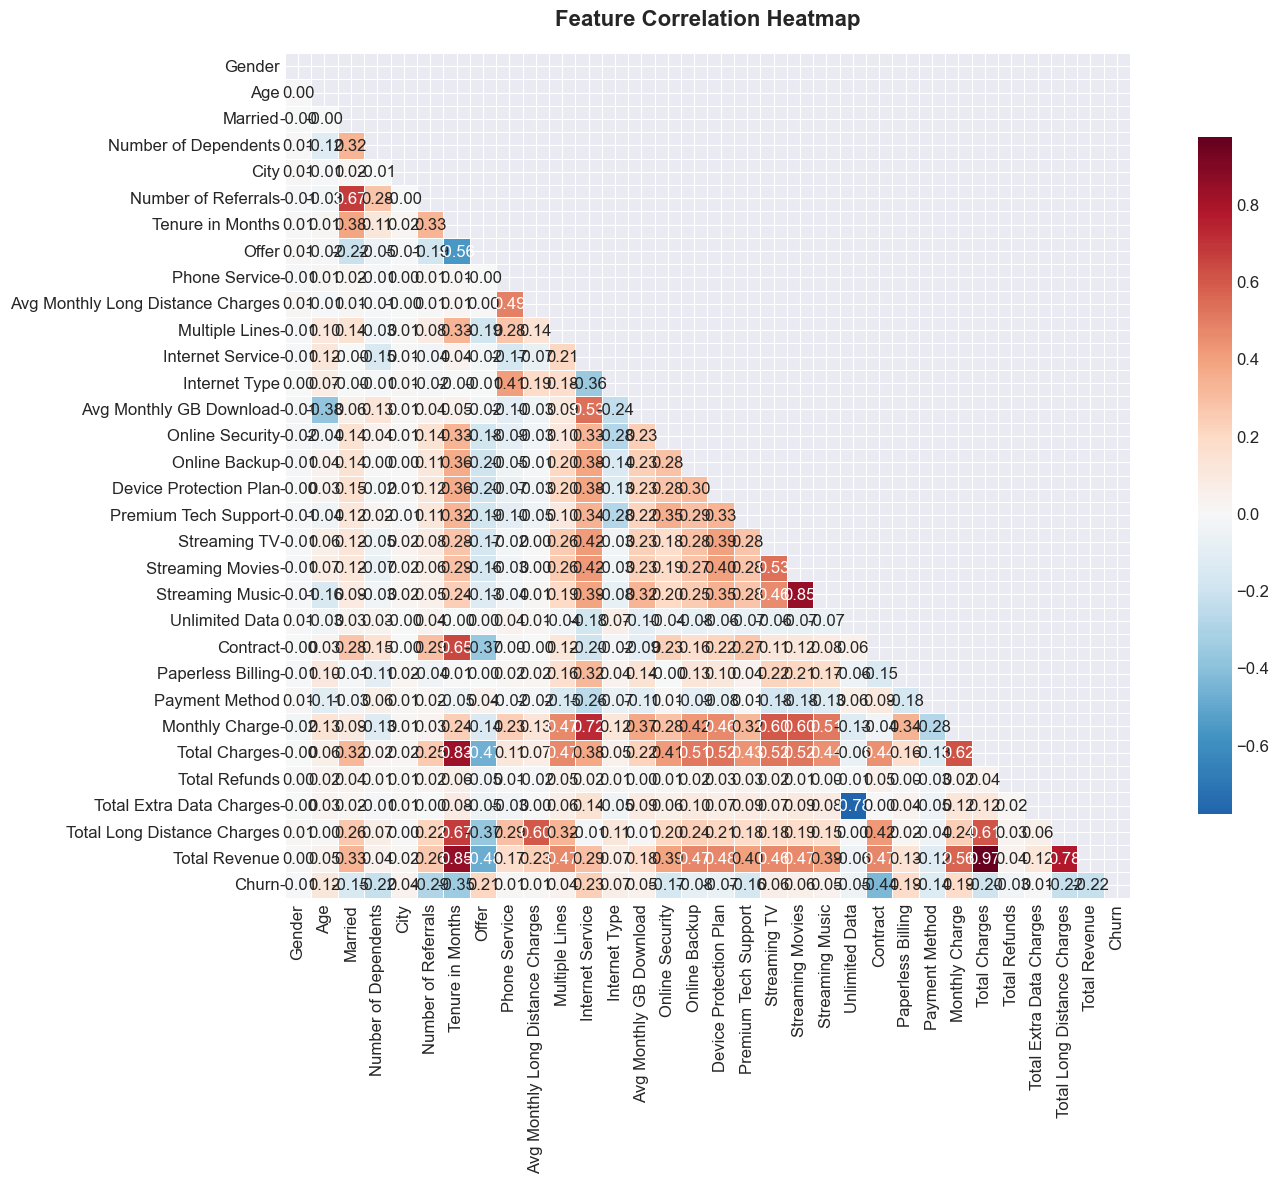


📊 Top Feature Correlations with Churn:
  Contract                  -0.435  █████████████
  Tenure in Months          -0.353  ██████████
  Number of Referrals       -0.287  ████████
  Internet Service          +0.228  ██████
  Total Long Distance Charges -0.224  ██████
  Total Revenue             -0.223  ██████
  Number of Dependents      -0.219  ██████
  Offer                     +0.209  ██████
  Total Charges             -0.199  █████
  Paperless Billing         +0.192  █████
  Monthly Charge            +0.188  █████
  Online Security           -0.171  █████
  Premium Tech Support      -0.165  ████
  Married                   -0.150  ████
  Payment Method            -0.135  ████
  Age                       +0.116  ███
  Online Backup             -0.082  ██
  Internet Type             +0.067  ██
  Device Protection Plan    -0.066  █
  Streaming TV              +0.063  █
  Streaming Movies          +0.061  █
  Unlimited Data            -0.051  █
  Avg Monthly GB Download   +0.049  █
  

In [12]:
# Encode for correlation
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Correlation heatmap
plt.figure(figsize=(16, 12))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with Churn
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print("\n📊 Top Feature Correlations with Churn:")
print("=" * 45)
for feat, corr in churn_corr.items():
    bar = '█' * int(abs(corr) * 30)
    sign = '+' if corr > 0 else '-'
    print(f"  {feat:25s} {sign}{abs(corr):.3f}  {bar}")


### 3.5 Key Insights

In [13]:
# Key churn insights
print("=" * 60)
print("📋 KEY INSIGHTS FROM EDA")
print("=" * 60)
print()
print(f"1. 📊 Overall Churn Rate: {(df['Churn'] == 1).mean():.1%}")
print("2. 📅 Tenure: Newer customers (low tenure) churn more")
print("3. 💰 Monthly Charges: Higher charges correlate with churn")
print("4. 👥 Married customers: May have different churn patterns")
print("5. 📝 Contract Types: Month-to-month likely higher churn")
print("6. 🌐 Internet Type: Fiber Optic vs Cable vs DSL patterns")
print("7. 🛡️ Services: Online Security/Backup/Tech Support impact")
print("8. 🎬 Streaming: Streaming service adoption vs churn")
print("9. 💳 Payment Method: Electronic check may indicate churn risk")
print("10.📊 Offers: Custom offers may correlate with retention")
print()
print(f"Most frequent churn reasons (if available):")
print(df['Churn'].value_counts())

📋 KEY INSIGHTS FROM EDA

1. 📊 Overall Churn Rate: 26.5%
2. 📅 Tenure: Newer customers (low tenure) churn more
3. 💰 Monthly Charges: Higher charges correlate with churn
4. 👥 Married customers: May have different churn patterns
5. 📝 Contract Types: Month-to-month likely higher churn
6. 🌐 Internet Type: Fiber Optic vs Cable vs DSL patterns
7. 🛡️ Services: Online Security/Backup/Tech Support impact
8. 🎬 Streaming: Streaming service adoption vs churn
9. 💳 Payment Method: Electronic check may indicate churn risk
10.📊 Offers: Custom offers may correlate with retention

Most frequent churn reasons (if available):
Churn
0    5174
1    1869
Name: count, dtype: int64


## 4. Feature Engineering & Data Preparation

In [14]:
# Prepare features
df_model = df.copy()

# Target is already binary (0/1)
target = df_model['Churn']
df_model = df_model.drop('Churn', axis=1)

# One-hot encode categorical variables
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Add back the target
df_model['Churn'] = target

print(f"\nShape after encoding: {df_model.shape}")
print(f"Features: {df_model.shape[1] - 1}")
df_model.head()

Categorical columns to encode: ['Gender', 'Married', 'City', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']

Shape after encoding: (7043, 1142)
Features: 1141


,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,...,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check,Churn
0,37,0,2,9,42.39,16.0,65.6,593.30,0.00,0,...,True,False,False,True,True,False,True,True,False,0
1,46,0,0,9,10.69,10.0,-4.0,542.40,38.33,10,...,False,True,True,False,False,False,False,True,False,0
2,50,0,0,4,33.65,30.0,73.9,280.85,0.00,0,...,False,False,False,True,False,False,True,False,False,1
3,78,0,1,13,27.82,4.0,98.0,1237.85,0.00,0,...,True,True,False,True,False,False,True,False,False,1
4,75,0,3,3,7.38,11.0,83.9,267.40,0.00,0,...,True,False,False,True,False,False,True,True,False,1


In [15]:
# Split features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Save feature names for later use
feature_names = X.columns.tolist()
print(f"Number of features: {len(feature_names)}")
print(f"\nFeatures:")
for i, feat in enumerate(feature_names, 1):
    print(f"  {i:2d}. {feat}")

print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nChurn ratio: {y.mean():.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")

Number of features: 1141

Features:
   1. Age
   2. Number of Dependents
   3. Number of Referrals
   4. Tenure in Months
   5. Avg Monthly Long Distance Charges
   6. Avg Monthly GB Download
   7. Monthly Charge
   8. Total Charges
   9. Total Refunds
  10. Total Extra Data Charges
  11. Total Long Distance Charges
  12. Total Revenue
  13. Gender_Male
  14. Married_Yes
  15. City_Acton
  16. City_Adelanto
  17. City_Adin
  18. City_Agoura Hills
  19. City_Aguanga
  20. City_Ahwahnee
  21. City_Alameda
  22. City_Alamo
  23. City_Albany
  24. City_Albion
  25. City_Alderpoint
  26. City_Alhambra
  27. City_Aliso Viejo
  28. City_Alleghany
  29. City_Alpaugh
  30. City_Alpine
  31. City_Alta
  32. City_Altadena
  33. City_Alturas
  34. City_Alviso
  35. City_Amador City
  36. City_Amboy
  37. City_Anaheim
  38. City_Anderson
  39. City_Angels Camp
  40. City_Angelus Oaks
  41. City_Angwin
  42. City_Annapolis
  43. City_Antelope
  44. City_Antioch
  45. City_Anza
  46. City_Apple Valle

In [16]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"After SMOTE:  {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")
print("\n✅ Feature scaling and SMOTE complete!")


Before SMOTE: {np.int64(0): np.int64(4139), np.int64(1): np.int64(1495)}
After SMOTE:  {np.int64(0): np.int64(4139), np.int64(1): np.int64(4139)}

✅ Feature scaling and SMOTE complete!


## 5. Model Training & Comparison

In [17]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, 
                                             min_samples_split=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, 
                                                     learning_rate=0.1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              use_label_encoder=False, eval_metric='logloss',
                              random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

# Train and evaluate each model
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 80)
print("MODEL TRAINING & EVALUATION")
print("=" * 80)

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    
    # Train
    model.fit(X_train_smote, y_train_smote)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='roc_auc')
    
    results[name] = {
        'model': model,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"  ✅ Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    print(f"     F1-Score: {f1:.4f} | ROC-AUC: {auc:.4f}")
    print(f"     CV ROC-AUC: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

print("\n" + "=" * 80)
print("✅ All models trained successfully!")


MODEL TRAINING & EVALUATION

🔄 Training Logistic Regression...
  ✅ Accuracy: 0.7722 | Precision: 0.5593 | Recall: 0.6684
     F1-Score: 0.6090 | ROC-AUC: 0.8246
     CV ROC-AUC: 0.8966 (±0.0040)

🔄 Training Random Forest...
  ✅ Accuracy: 0.7991 | Precision: 0.6032 | Recall: 0.7112
     F1-Score: 0.6528 | ROC-AUC: 0.8792
     CV ROC-AUC: 0.9499 (±0.0034)

🔄 Training Gradient Boosting...
  ✅ Accuracy: 0.8424 | Precision: 0.6979 | Recall: 0.7166
     F1-Score: 0.7071 | ROC-AUC: 0.9103
     CV ROC-AUC: 0.9668 (±0.0021)

🔄 Training XGBoost...
  ✅ Accuracy: 0.8524 | Precision: 0.7306 | Recall: 0.7032
     F1-Score: 0.7166 | ROC-AUC: 0.9112
     CV ROC-AUC: 0.9681 (±0.0025)

🔄 Training SVM...
  ✅ Accuracy: 0.7346 | Precision: 0.5000 | Recall: 0.4947
     F1-Score: 0.4973 | ROC-AUC: 0.7850
     CV ROC-AUC: 0.8980 (±0.0053)

✅ All models trained successfully!


## 6. Model Evaluation & Selection

### 6.1 Performance Comparison

In [18]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1_score'],
        'ROC-AUC': r['roc_auc'],
        'CV ROC-AUC': r['cv_mean']
    } for name, r in results.items()
}).T

comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)
print("\n📊 MODEL PERFORMANCE COMPARISON")
print("=" * 80)
print(comparison_df.to_string())

# Highlight best model
best_model_name = comparison_df['ROC-AUC'].idxmax()
print(f"\n🏆 Best Model: {best_model_name} (ROC-AUC: {comparison_df.loc[best_model_name, 'ROC-AUC']:.4f})")



📊 MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC  CV ROC-AUC
XGBoost              0.852378   0.730556  0.703209  0.716621  0.911214    0.968109
Gradient Boosting    0.842441   0.697917  0.716578  0.707124  0.910264    0.966804
Random Forest        0.799148   0.603175  0.711230  0.652761  0.879178    0.949872
Logistic Regression  0.772179   0.559284  0.668449  0.609013  0.824630    0.896567
SVM                  0.734564   0.500000  0.494652  0.497312  0.784985    0.898023

🏆 Best Model: XGBoost (ROC-AUC: 0.9112)


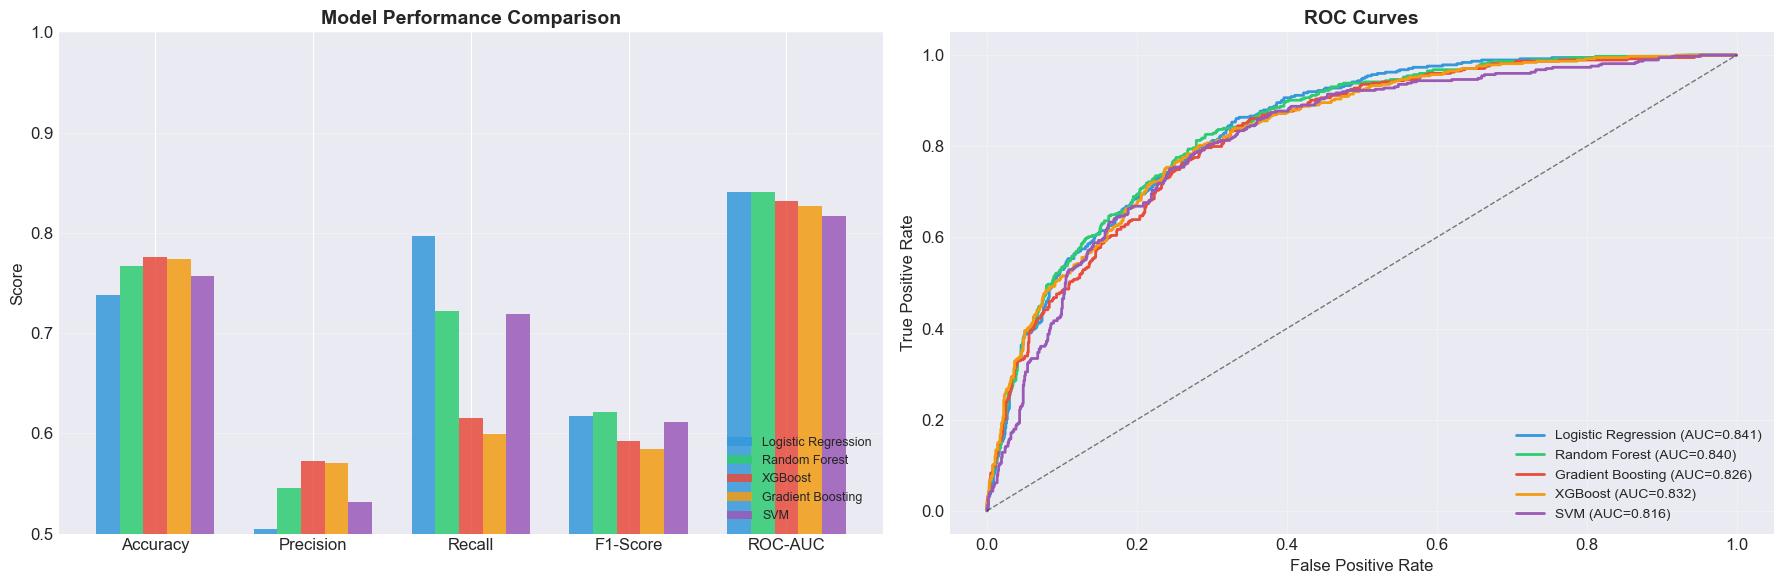

In [21]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.15
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, (name, row) in enumerate(comparison_df.iterrows()):
    axes[0].bar(x + i * width, [row[m] for m in metrics], width, 
                label=name, color=colors_models[i], alpha=0.85)

axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(metrics)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# ROC Curves
for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, r['y_pred_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})", 
                 color=colors_models[i], linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Best Model — Detailed Analysis

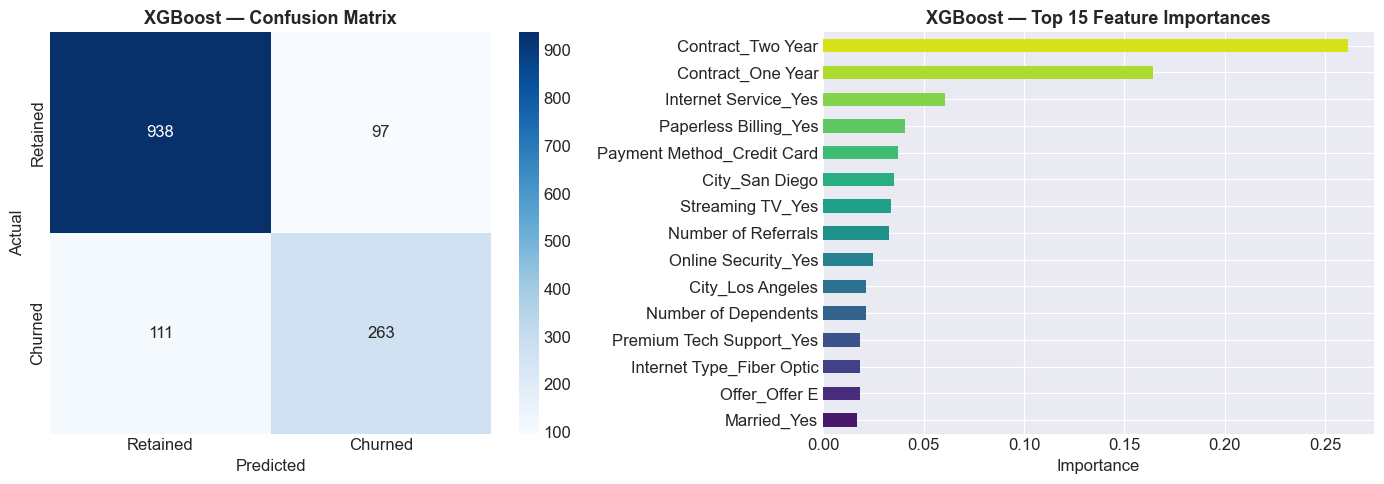


📋 Classification Report — XGBoost
              precision    recall  f1-score   support

    Retained       0.89      0.91      0.90      1035
     Churned       0.73      0.70      0.72       374

    accuracy                           0.85      1409
   macro avg       0.81      0.80      0.81      1409
weighted avg       0.85      0.85      0.85      1409



In [19]:
# Best model confusion matrix & classification report
best_result = results[best_model_name]
y_pred_best = best_result['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[0].set_title(f'{best_model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature Importance (if available)
if hasattr(best_result['model'], 'feature_importances_'):
    importances = best_result['model'].feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True).tail(15)
    feat_imp.plot(kind='barh', ax=axes[1], color=sns.color_palette('viridis', 15))
    axes[1].set_title(f'{best_model_name} — Top 15 Feature Importances', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Importance')
else:
    # Use coefficients for linear models
    coefs = np.abs(best_result['model'].coef_[0])
    feat_imp = pd.Series(coefs, index=feature_names).sort_values(ascending=True).tail(15)
    feat_imp.plot(kind='barh', ax=axes[1], color=sns.color_palette('viridis', 15))
    axes[1].set_title(f'{best_model_name} — Top 15 Feature Coefficients', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('best_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📋 Classification Report — {best_model_name}")
print("=" * 60)
print(classification_report(y_test, y_pred_best, target_names=['Retained', 'Churned']))

## 7. Save Best Model & Pipeline

In [20]:
# Save the best model, scaler, and feature names
best_model = best_result['model']

# Save model
joblib.dump(best_model, 'churn_model.pkl')
print(f"✅ Best model ({best_model_name}) saved as 'churn_model.pkl'")

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as 'scaler.pkl'")

# Save feature names and column info for frontend
pipeline_info = {
    'feature_names': feature_names,
    'best_model_name': best_model_name,
    'accuracy': best_result['accuracy'],
    'roc_auc': best_result['roc_auc'],
    'f1_score': best_result['f1_score']
}
joblib.dump(pipeline_info, 'pipeline_info.pkl')
print("✅ Pipeline info saved as 'pipeline_info.pkl'")

print(f"\n🏆 Final Model Performance:")
print(f"   Model: {best_model_name}")
print(f"   Accuracy: {best_result['accuracy']:.4f}")
print(f"   ROC-AUC: {best_result['roc_auc']:.4f}")
print(f"   F1-Score: {best_result['f1_score']:.4f}")
print(f"\n✅ All artifacts saved! Ready for deployment.")


✅ Best model (XGBoost) saved as 'churn_model.pkl'
✅ Scaler saved as 'scaler.pkl'
✅ Pipeline info saved as 'pipeline_info.pkl'

🏆 Final Model Performance:
   Model: XGBoost
   Accuracy: 0.8524
   ROC-AUC: 0.9112
   F1-Score: 0.7166

✅ All artifacts saved! Ready for deployment.


In [21]:
# Save feature importances for the frontend visualization
if hasattr(best_model, 'feature_importances_'):
    importances_dict = dict(zip(feature_names, best_model.feature_importances_.tolist()))
else:
    importances_dict = dict(zip(feature_names, np.abs(best_model.coef_[0]).tolist()))

import json
with open('feature_importances.json', 'w') as f:
    json.dump(importances_dict, f, indent=2)
print("✅ Feature importances saved as 'feature_importances.json'")


✅ Feature importances saved as 'feature_importances.json'
